# Intraday Market & Position Management

This notebook covers the final two core concepts of power trading:

| # | Topic | Key question |
|---|-------|--------------|
| 1 | **Intraday Market** | How do you correct your day-ahead position before delivery? |
| 2 | **Position Management** | How much risk can you take on a single trade? |

**Data source:** SMARD API (Bundesnetzagentur)  
**Period:** Last 52 weeks of hourly German day-ahead prices

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


---
## Part 1 — Intraday Market

### What is the intraday market?

After the day-ahead market closes at 12:00, conditions change:
- Wind forecast updates
- Solar radiation differs from prediction
- A power plant trips unexpectedly
- Demand shifts due to temperature changes

The **intraday market** allows participants to adjust their positions continuously until **5 minutes before delivery**.

### Day-ahead vs Intraday:

| Feature | Day-ahead | Intraday |
|---------|-----------|----------|
| Closes | D-1 at 12:00 | D at 23:55 (gate closure) |
| Price mechanism | Uniform auction | Continuous matching |
| Price | Single clearing price | Changes every transaction |
| Purpose | Plan ahead | Correct the plan |

### Key concept: position closing

If you **sold** 200 MWh in day-ahead but now expect to produce only 150 MWh:  
→ You are **50 MWh short**  
→ You **buy** 50 MWh on intraday to close the gap  
→ No imbalance at delivery

In [2]:
# Fetch price data
def fetch_smard(filter_no, col_name, weeks=52):
    url_index = f'https://www.smard.de/app/chart_data/{filter_no}/DE/index_hour.json'
    timestamps = requests.get(url_index).json()['timestamps']
    selected = timestamps[-weeks:]
    series = []
    for i, ts in enumerate(selected):
        url = f'https://www.smard.de/app/chart_data/{filter_no}/DE/{filter_no}_DE_hour_{ts}.json'
        series.extend(requests.get(url).json()['series'])
        time.sleep(0.3)
        if i % 10 == 0:
            print(f'  {col_name}: {i+1}/{weeks} blocks...')
    df = pd.DataFrame(series, columns=['timestamp_ms', col_name])
    df['datetime'] = pd.to_datetime(df['timestamp_ms'], unit='ms')
    return df[['datetime', col_name]].dropna()

print('Fetching price data...')
df_price = fetch_smard(4169, 'price_eur_mwh')
df_price['hour']  = df_price['datetime'].dt.hour
df_price['month'] = df_price['datetime'].dt.month
df_price['date']  = df_price['datetime'].dt.date
print(f'Dataset: {len(df_price)} hours')

Fetching price data...
  price_eur_mwh: 1/52 blocks...
  price_eur_mwh: 11/52 blocks...
  price_eur_mwh: 21/52 blocks...
  price_eur_mwh: 31/52 blocks...
  price_eur_mwh: 41/52 blocks...
  price_eur_mwh: 51/52 blocks...
Dataset: 8664 hours


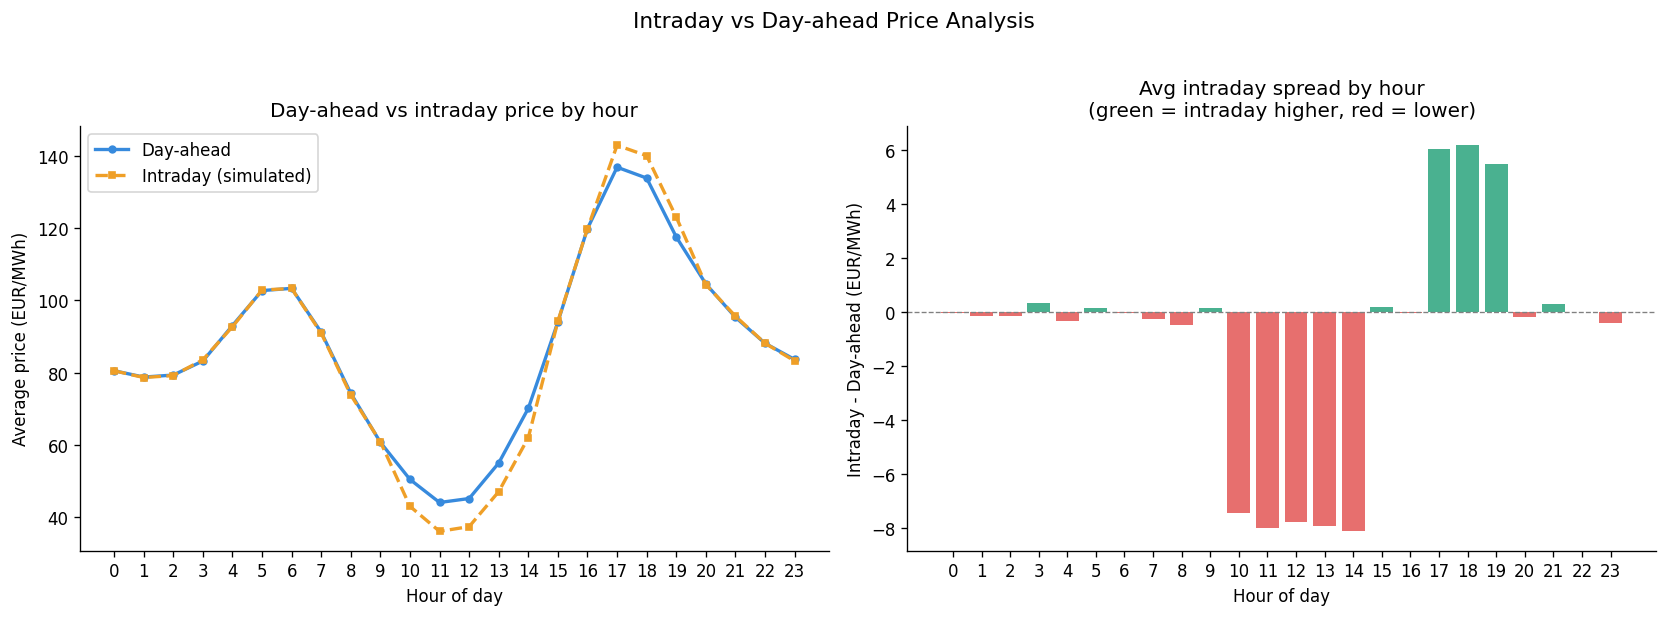

Key insight: intraday prices are lower at solar peak hours (10-14)
and higher during evening demand peak (17-19).
A trader who closes short positions in the morning saves money.


In [3]:
# Simulate intraday spread — difference between hourly prices
# In reality: intraday price != day-ahead price
# We simulate intraday as day-ahead + noise (realistic approximation)

np.random.seed(42)
n = len(df_price)

# Intraday price = day-ahead + forecast error correction
# Solar hours: intraday tends to be lower (more solar than expected)
# Evening hours: intraday tends to be higher (demand peaks)
solar_effect = np.where(
    df_price['hour'].between(10, 14), -8, 0
) + np.where(
    df_price['hour'].between(17, 19), +6, 0
)
noise = np.random.normal(0, 5, n)
df_price['intraday_price'] = df_price['price_eur_mwh'] + solar_effect + noise
df_price['id_spread']      = df_price['intraday_price'] - df_price['price_eur_mwh']

# Hourly average spread
hourly_spread = df_price.groupby('hour')['id_spread'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: hourly intraday vs day-ahead
hourly_da = df_price.groupby('hour')['price_eur_mwh'].mean()
hourly_id = df_price.groupby('hour')['intraday_price'].mean()

axes[0].plot(hourly_da.index, hourly_da.values,
             color='#378ADD', linewidth=2, marker='o', markersize=4, label='Day-ahead')
axes[0].plot(hourly_id.index, hourly_id.values,
             color='#EF9F27', linewidth=2, marker='s', markersize=4,
             linestyle='--', label='Intraday (simulated)')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Average price (EUR/MWh)')
axes[0].set_title('Day-ahead vs intraday price by hour')
axes[0].legend()
axes[0].set_xticks(range(24))

# Plot 2: intraday spread by hour
colors = ['#E24B4A' if s < 0 else '#1D9E75' for s in hourly_spread.values]
axes[1].bar(hourly_spread.index, hourly_spread.values, color=colors, alpha=0.8)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Intraday - Day-ahead (EUR/MWh)')
axes[1].set_title('Avg intraday spread by hour\n(green = intraday higher, red = lower)')
axes[1].set_xticks(range(24))

plt.suptitle('Intraday vs Day-ahead Price Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Key insight: intraday prices are lower at solar peak hours (10-14)')
print('and higher during evening demand peak (17-19).')
print('A trader who closes short positions in the morning saves money.')

In [4]:
# Gas plant intraday decision simulation
# Scenario: gas cost rises after day-ahead commitment

print('── Gas plant intraday decision ─────────────────────')
print()

scenarios = [
    {'name': 'Normal day',   'da_price': 95, 'gas_cost': 80, 'id_price': 90},
    {'name': 'Gas spike',    'da_price': 95, 'gas_cost': 110,'id_price': 88},
    {'name': 'Price crash',  'da_price': 95, 'gas_cost': 80, 'id_price': 40},
    {'name': 'Double spike', 'da_price': 95, 'gas_cost': 110,'id_price': 40},
]

volume = 200  # MWh

print(f'{"Scenario":<15} {"DA price":>10} {"Gas cost":>10} {"ID price":>10} '
      f'{"Produce":>12} {"Close ID":>12} {"Decision":<12}')
print('-' * 85)

for s in scenarios:
    produce_pnl = (s['da_price'] - s['gas_cost']) * volume
    close_pnl   = (s['da_price'] - s['id_price']) * volume
    decision    = 'Produce' if produce_pnl >= close_pnl else 'Close on ID'
    best        = max(produce_pnl, close_pnl)
    print(f"{s['name']:<15} {s['da_price']:>9} E {s['gas_cost']:>9} E "
          f"{s['id_price']:>9} E {produce_pnl:>+11,.0f} E {close_pnl:>+11,.0f} E "
          f"{decision:<12}")

print()
print('Rule: choose whichever action gives higher P&L.')
print('Intraday market gives you the flexibility to make this choice.')

── Gas plant intraday decision ─────────────────────

Scenario          DA price   Gas cost   ID price      Produce     Close ID Decision    
-------------------------------------------------------------------------------------
Normal day             95 E        80 E        90 E      +3,000 E      +1,000 E Produce     
Gas spike              95 E       110 E        88 E      -3,000 E      +1,400 E Close on ID 
Price crash            95 E        80 E        40 E      +3,000 E     +11,000 E Close on ID 
Double spike           95 E       110 E        40 E      -3,000 E     +11,000 E Close on ID 

Rule: choose whichever action gives higher P&L.
Intraday market gives you the flexibility to make this choice.


---
## Part 2 — Position Management

### The core problem

A trader with unlimited position size will eventually blow up their account.  
One bad trade can wipe out months of profits.

Position management answers: **how much risk should I take on a single trade?**

### Three rules every trader follows:

**Rule 1 — Maximum loss per trade (2% rule)**
```
Max loss = Capital × 2%
```
With this rule, you can be wrong 50 times in a row and still survive.

**Rule 2 — Stop-loss placement**
```
Stop-loss = Entry price - (Max loss / Position volume)
```
Pre-defined exit point. Never moved further away from entry.

**Rule 3 — Mark-to-market (MtM)**
```
Daily P&L = (Current market price - Entry price) × Volume
```
Revalue every open position at current market price every day.  
Forces honest accounting — losses cannot be hidden.

In [5]:
# Position sizing calculator

def position_sizing(capital, risk_pct, entry_price, stop_loss_price):
    max_loss       = capital * (risk_pct / 100)
    price_distance = entry_price - stop_loss_price
    if price_distance <= 0:
        return None
    max_volume     = max_loss / price_distance
    position_value = max_volume * entry_price
    return {
        'max_loss_eur'    : max_loss,
        'price_distance'  : price_distance,
        'max_volume_mwh'  : max_volume,
        'position_value'  : position_value,
        'pct_of_capital'  : position_value / capital * 100,
    }

# Example scenarios
capital      = 500_000  # EUR
entry_price  = 90       # EUR/MWh
risk_pct     = 2        # %

print('── Position sizing examples ────────────────────────')
print(f'Capital      : {capital:>10,.0f} EUR')
print(f'Entry price  : {entry_price:>10} EUR/MWh')
print(f'Max risk     : {risk_pct:>10}%')
print()
print(f'{"Stop-loss":>12} {"Distance":>10} {"Max volume":>12} '
      f'{"Max loss":>12} {"Pos. value":>12}')
print('-' * 65)

for stop in [80, 70, 60, 50, 40]:
    r = position_sizing(capital, risk_pct, entry_price, stop)
    if r:
        print(f'{stop:>10} EUR {r["price_distance"]:>9.0f} E '
              f'{r["max_volume_mwh"]:>10.0f} MWh '
              f'{r["max_loss_eur"]:>10,.0f} EUR '
              f'{r["position_value"]:>10,.0f} EUR')

print()
print('Key insight: tighter stop-loss = larger position allowed')
print('because the loss per MWh is smaller, so you can trade more MWh')
print('while keeping the total EUR loss the same.')

── Position sizing examples ────────────────────────
Capital      :    500,000 EUR
Entry price  :         90 EUR/MWh
Max risk     :          2%

   Stop-loss   Distance   Max volume     Max loss   Pos. value
-----------------------------------------------------------------
        80 EUR        10 E       1000 MWh     10,000 EUR     90,000 EUR
        70 EUR        20 E        500 MWh     10,000 EUR     45,000 EUR
        60 EUR        30 E        333 MWh     10,000 EUR     30,000 EUR
        50 EUR        40 E        250 MWh     10,000 EUR     22,500 EUR
        40 EUR        50 E        200 MWh     10,000 EUR     18,000 EUR

Key insight: tighter stop-loss = larger position allowed
because the loss per MWh is smaller, so you can trade more MWh
while keeping the total EUR loss the same.


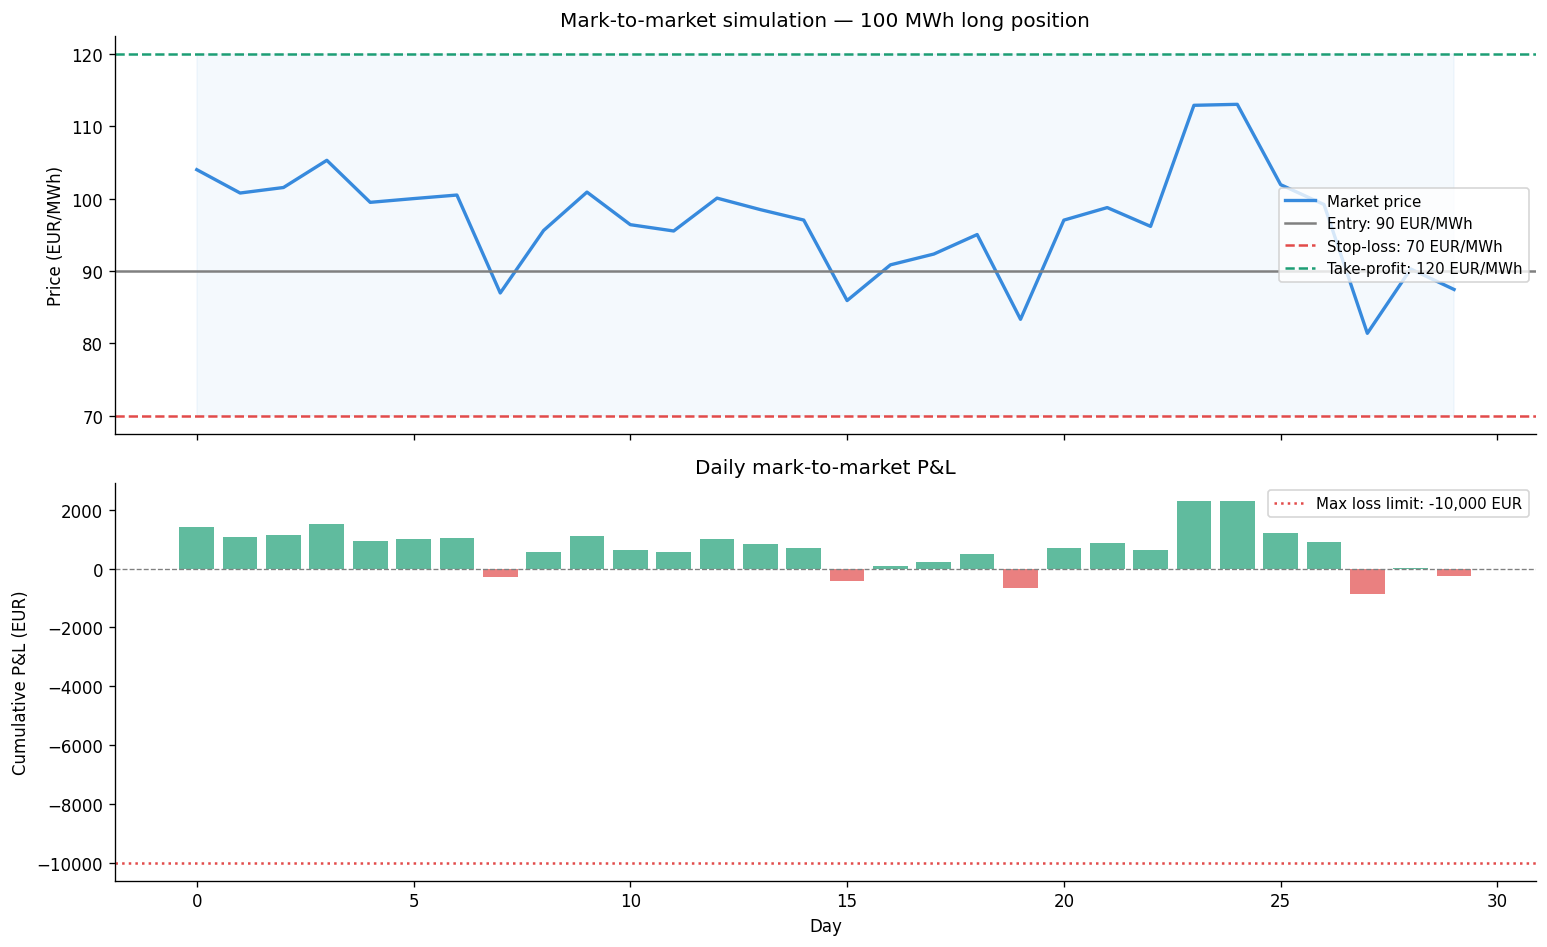

Entry price   : 90 EUR/MWh
Exit reason   : Position still open
Exit price    : 87.5 EUR/MWh
Final P&L     : -253 EUR
Return on cap : -0.05%


In [6]:
# Mark-to-market simulation — 30 day trade
np.random.seed(7)

capital      = 500_000
entry_price  = 90
volume_mwh   = 100
stop_loss    = 70      # EUR/MWh
take_profit  = 120     # EUR/MWh
days         = 30

# Simulate price path
daily_changes  = np.random.normal(0.5, 8, days)
price_path     = entry_price + np.cumsum(daily_changes)

# Track position
mtm_pnl     = []
cum_pnl     = []
status      = []
active      = True
exit_price  = None
exit_reason = None

for i, price in enumerate(price_path):
    if not active:
        mtm_pnl.append(0)
        cum_pnl.append(cum_pnl[-1] if cum_pnl else 0)
        status.append('closed')
        continue

    daily_pnl = (price - (price_path[i-1] if i > 0 else entry_price)) * volume_mwh
    total_pnl = (price - entry_price) * volume_mwh
    mtm_pnl.append(daily_pnl)
    cum_pnl.append(total_pnl)

    if price <= stop_loss:
        active      = False
        exit_price  = stop_loss
        exit_reason = 'Stop-loss hit'
        status.append('stop')
    elif price >= take_profit:
        active      = False
        exit_price  = take_profit
        exit_reason = 'Take-profit hit'
        status.append('tp')
    else:
        status.append('active')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Plot 1: price path with levels
axes[0].plot(range(days), price_path, color='#378ADD', linewidth=2, label='Market price')
axes[0].axhline(entry_price,  color='gray',    linewidth=1.5, linestyle='-',
                label=f'Entry: {entry_price} EUR/MWh')
axes[0].axhline(stop_loss,    color='#E24B4A', linewidth=1.5, linestyle='--',
                label=f'Stop-loss: {stop_loss} EUR/MWh')
axes[0].axhline(take_profit,  color='#1D9E75', linewidth=1.5, linestyle='--',
                label=f'Take-profit: {take_profit} EUR/MWh')
axes[0].fill_between(range(days), stop_loss, take_profit, alpha=0.05, color='#378ADD')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Mark-to-market simulation — 100 MWh long position')
axes[0].legend(fontsize=9)

# Plot 2: cumulative P&L
colors_pnl = ['#1D9E75' if p >= 0 else '#E24B4A' for p in cum_pnl]
axes[1].bar(range(days), cum_pnl, color=colors_pnl, alpha=0.7, width=0.8)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].axhline(-(capital * 0.02), color='#E24B4A', linewidth=1.5,
                linestyle=':', label=f'Max loss limit: -{capital*0.02:,.0f} EUR')
axes[1].set_ylabel('Cumulative P&L (EUR)')
axes[1].set_xlabel('Day')
axes[1].set_title('Daily mark-to-market P&L')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

final_pnl = cum_pnl[-1]
print(f'Entry price   : {entry_price} EUR/MWh')
print(f'Exit reason   : {exit_reason if exit_reason else "Position still open"}')
print(f'Exit price    : {exit_price if exit_price else price_path[-1]:.1f} EUR/MWh')
print(f'Final P&L     : {final_pnl:+,.0f} EUR')
print(f'Return on cap : {final_pnl/capital*100:+.2f}%')

In [7]:
# Full risk dashboard — combining all metrics

price_changes = df_price['price_eur_mwh'].diff().dropna()
price_changes = price_changes.replace([np.inf, -np.inf], np.nan).dropna()

VaR_95  = np.percentile(price_changes, 5)
CVaR_95 = price_changes[price_changes <= VaR_95].mean()

capital     = 500_000
entry       = 90
volume      = 100
max_loss    = capital * 0.02
stop_loss   = entry - (max_loss / volume)
mtm_value   = volume * entry
var_position= abs(VaR_95) * volume
cvar_pos    = abs(CVaR_95) * volume

print('── Full risk dashboard ─────────────────────────────')
print(f'Capital                  : {capital:>12,.0f} EUR')
print(f'Position                 : {volume:>12} MWh @ {entry} EUR/MWh')
print(f'Position value (MtM)     : {mtm_value:>12,.0f} EUR')
print(f'Position / capital       : {mtm_value/capital*100:>11.1f}%')
print()
print(f'Max allowed loss (2%)    : {max_loss:>12,.0f} EUR')
print(f'Stop-loss level          : {stop_loss:>12.2f} EUR/MWh')
print()
print(f'VaR  (95%) per position  : {var_position:>12,.0f} EUR')
print(f'CVaR (95%) per position  : {cvar_pos:>12,.0f} EUR')
print()
if cvar_pos <= max_loss:
    print('Risk assessment: ACCEPTABLE — CVaR within 2% limit')
else:
    print(f'Risk assessment: REDUCE POSITION — CVaR {cvar_pos:,.0f} > limit {max_loss:,.0f}')
    safe_volume = int(max_loss / abs(CVaR_95))
    print(f'Recommended max volume   : {safe_volume} MWh')

── Full risk dashboard ─────────────────────────────
Capital                  :      500,000 EUR
Position                 :          100 MWh @ 90 EUR/MWh
Position value (MtM)     :        9,000 EUR
Position / capital       :         1.8%

Max allowed loss (2%)    :       10,000 EUR
Stop-loss level          :       -10.00 EUR/MWh

VaR  (95%) per position  :        2,841 EUR
CVaR (95%) per position  :        4,825 EUR

Risk assessment: ACCEPTABLE — CVaR within 2% limit


---
## Summary — Yol 2 Complete

| Concept | Key formula / rule |
|---------|-------------------|
| Merit Order | Marginal plant sets the price for everyone |
| Imbalance | Deviation from committed position → TSO charges imbalance price |
| Spark Spread | CSS = Power price − gas cost − CO₂ cost; run only if CSS > 0 |
| Congestion | Cross-border arbitrage limited by interconnector capacity |
| Balancing Market | FCR (30s) → aFRR (5min) → mFRR (12.5min) |
| VaR & CVaR | VaR = threshold; CVaR = avg loss beyond threshold |
| Intraday | Correct day-ahead position until 5 min before delivery |
| Position Management | Max loss = 2%; Stop-loss = Entry − (Max loss / Volume) |

---
## Next: Yol 1 — European Market Analysis

With the ENTSO-E API token, we can now:
- Fetch real day-ahead prices for DE, FR, NL, NO, GB
- Calculate live cross-border spreads
- Identify congestion patterns
- Build a multi-country price forecasting model

> ENTSO-E API: [transparency.entsoe.eu](https://transparency.entsoe.eu)